In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_test.csv
/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_train.csv


In [8]:
# ============================================================
#  HANDWRITTEN DIGIT RECOGNITION USING ANN — MNIST DATASET
#  Domain  : Computer Vision / Pattern Recognition
#  Tools   : Python | TensorFlow/Keras | Sklearn | Seaborn
#  Dataset : MNIST (CSV) from Kaggle
# ============================================================

# ── 0. INSTALL / IMPORTS ────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score,
                             recall_score, f1_score, ConfusionMatrixDisplay)
from sklearn.utils import shuffle

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version :", tf.__version__)
print("Keras version      :", keras.__version__)

# ── STYLE ────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f0f1a",
    "axes.facecolor":   "#0f0f1a",
    "axes.edgecolor":   "#444",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#aaa",
    "ytick.color":      "#aaa",
    "text.color":       "#e0e0e0",
    "grid.color":       "#333",
    "grid.linestyle":   "--",
    "font.family":      "monospace",
})
ACCENT  = "#00e5ff"
ACCENT2 = "#ff4081"
CMAP    = "plasma"


TensorFlow version : 2.19.0
Keras version      : 3.10.0


In [12]:
# ════════════════════════════════════════════════════════════
#  1. LOAD DATA
# ════════════════════════════════════════════════════════════
# ── Kaggle path (works in any Kaggle notebook) ──────────────
TRAIN_PATH = "/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_train.csv"
TEST_PATH  = "/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_test.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f"\nTrain shape : {train_df.shape}")
print(f"Test  shape : {test_df.shape}")
print(f"\nColumn names (first 5): {list(train_df.columns[:5])}")
train_df.head(3)



Train shape : (60000, 785)
Test  shape : (10000, 785)

Column names (first 5): ['label', '1x1', '1x2', '1x3', '1x4']


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



── TRAIN INFO ──────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB
None

── DESCRIPTIVE STATS (first 5 pixel cols) ──────
         count      mean      std  min  25%  50%  75%  max
label  60000.0  4.453933  2.88927  0.0  2.0  4.0  7.0  9.0
1x1    60000.0  0.000000  0.00000  0.0  0.0  0.0  0.0  0.0
1x2    60000.0  0.000000  0.00000  0.0  0.0  0.0  0.0  0.0
1x3    60000.0  0.000000  0.00000  0.0  0.0  0.0  0.0  0.0
1x4    60000.0  0.000000  0.00000  0.0  0.0  0.0  0.0  0.0
1x5    60000.0  0.000000  0.00000  0.0  0.0  0.0  0.0  0.0

Missing values (train): 0
Missing values (test) : 0
Unique labels         : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


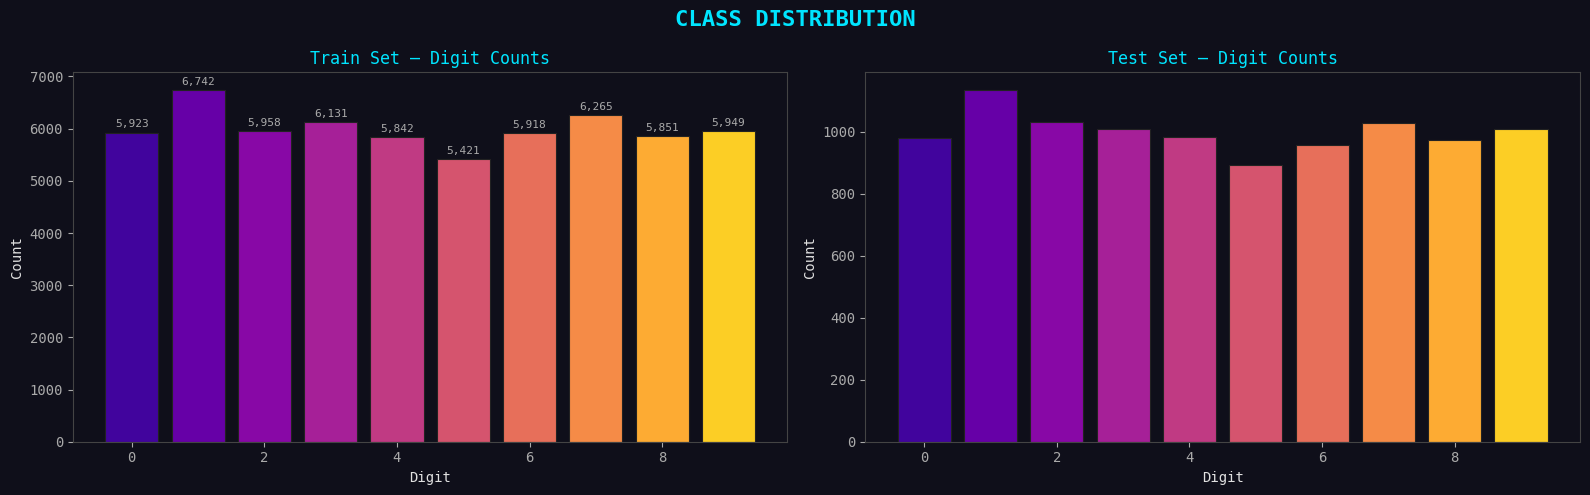

Saved → 01_class_distribution.png


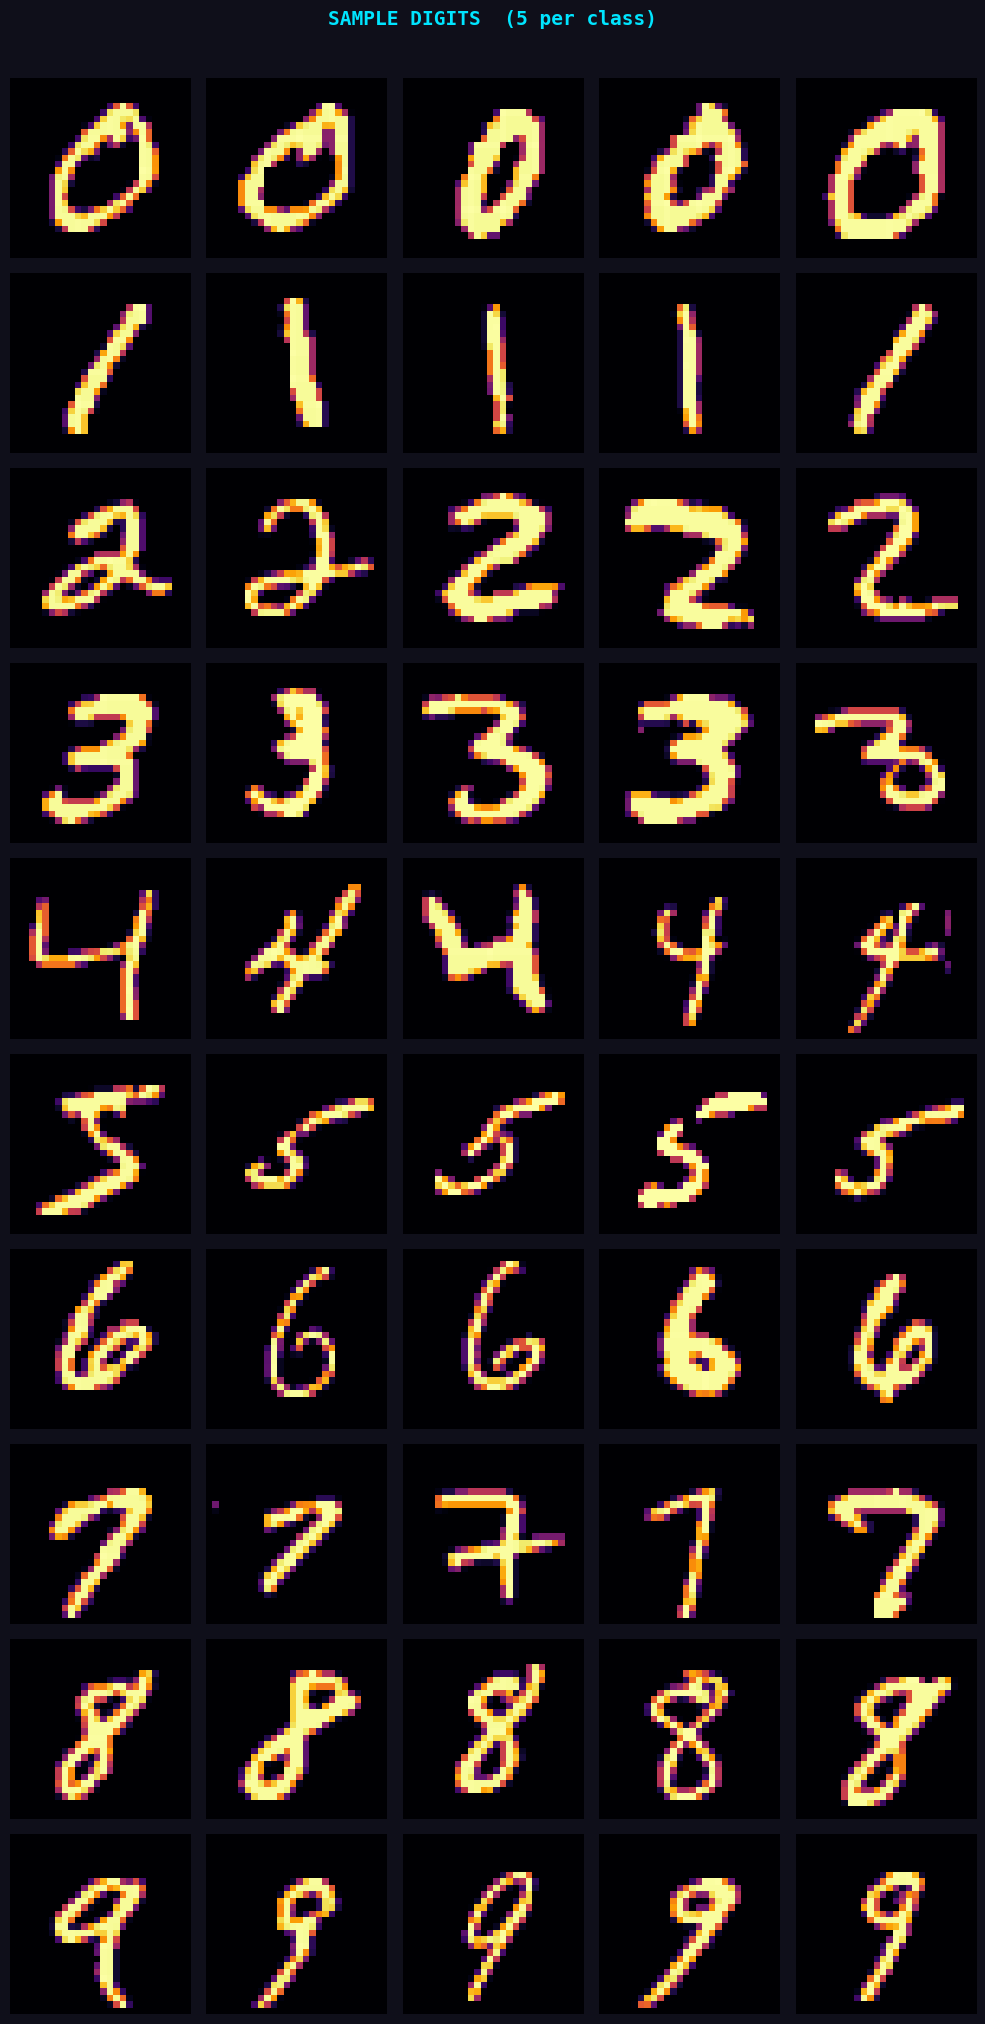

Saved → 02_sample_digits.png


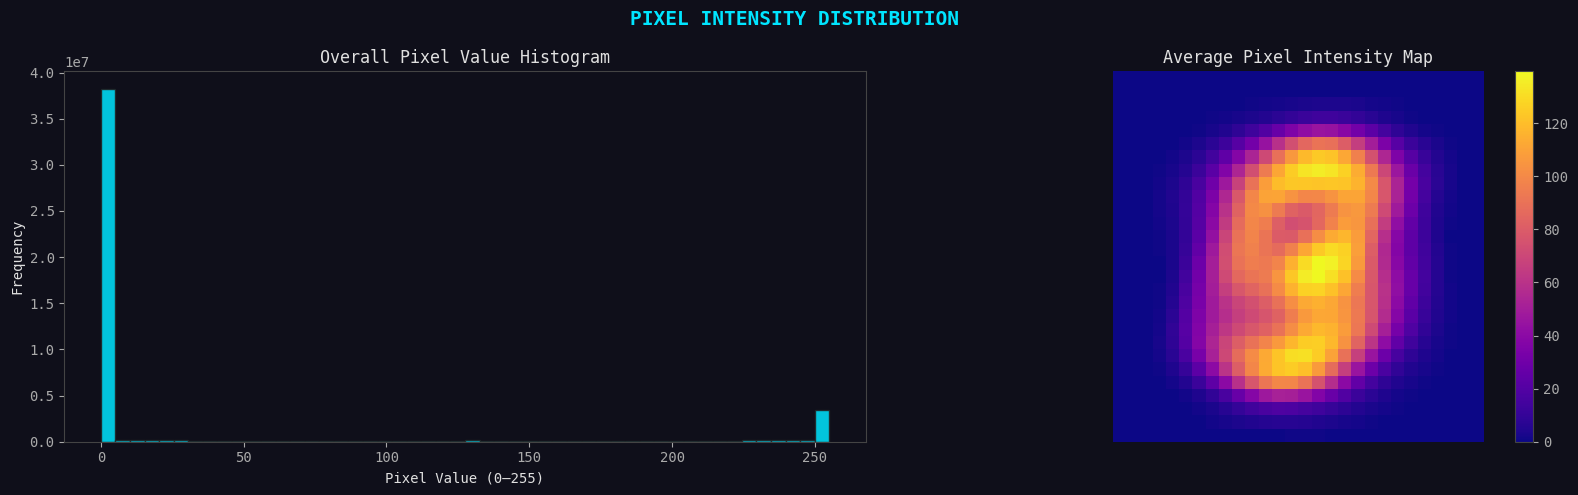

Saved → 03_pixel_intensity.png


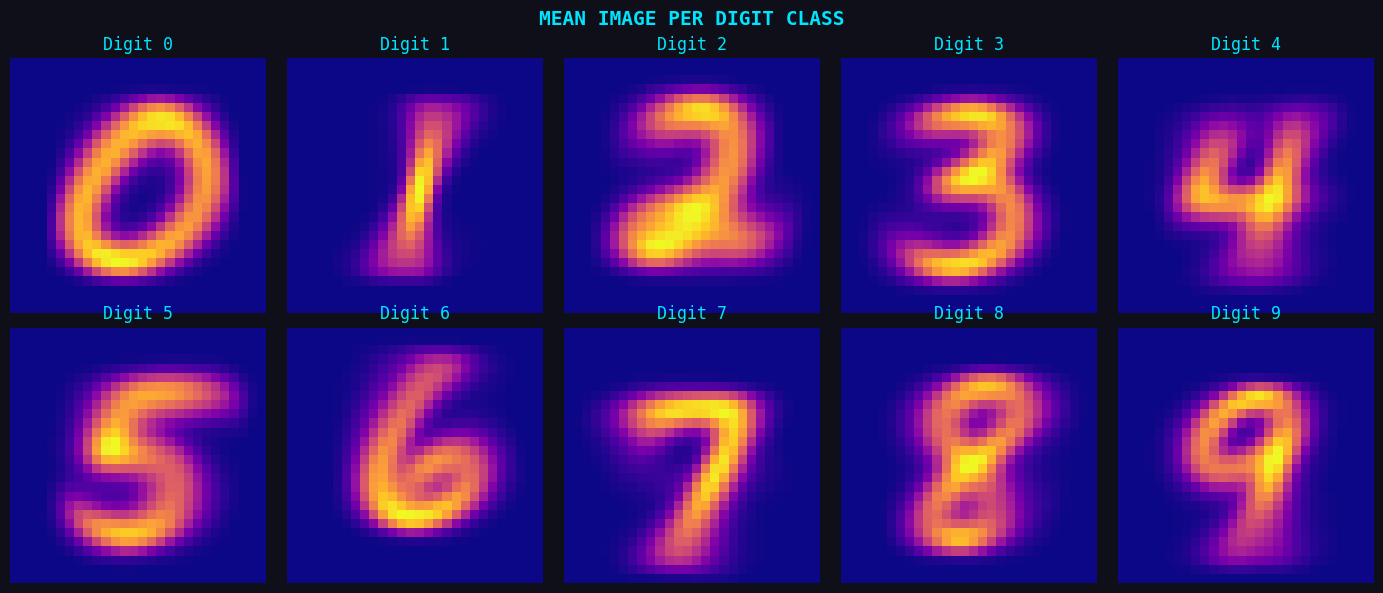

Saved → 04_mean_images.png


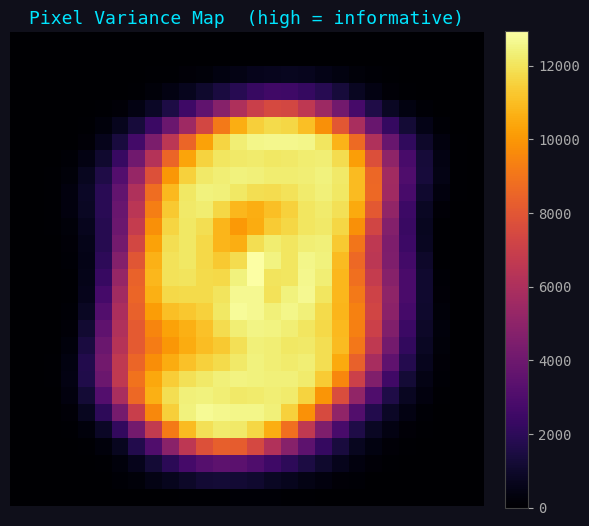

Saved → 05_variance_map.png


In [13]:
# ════════════════════════════════════════════════════════════
#  2. EXPLORATORY DATA ANALYSIS  (EDA)
# ════════════════════════════════════════════════════════════

# ── 2.1  Basic Info ─────────────────────────────────────────
print("\n── TRAIN INFO ──────────────────────────────────")
print(train_df.info())
print("\n── DESCRIPTIVE STATS (first 5 pixel cols) ──────")
print(train_df.iloc[:, :6].describe().T)

print(f"\nMissing values (train): {train_df.isnull().sum().sum()}")
print(f"Missing values (test) : {test_df.isnull().sum().sum()}")
print(f"Unique labels         : {sorted(train_df['label'].unique())}")

# ── 2.2  Class Distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("CLASS DISTRIBUTION", fontsize=16, color=ACCENT, fontweight="bold")

counts = train_df["label"].value_counts().sort_index()
axes[0].bar(counts.index, counts.values,
            color=plt.cm.plasma(np.linspace(0.1, 0.9, 10)), edgecolor="#222", linewidth=0.8)
axes[0].set_title("Train Set — Digit Counts", color=ACCENT)
axes[0].set_xlabel("Digit")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f"{v:,}", ha="center", fontsize=8, color="#aaa")

counts_t = test_df["label"].value_counts().sort_index()
axes[1].bar(counts_t.index, counts_t.values,
            color=plt.cm.plasma(np.linspace(0.1, 0.9, 10)), edgecolor="#222", linewidth=0.8)
axes[1].set_title("Test Set — Digit Counts", color=ACCENT)
axes[1].set_xlabel("Digit")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 01_class_distribution.png")

# ── 2.3  Sample Images (5 per class) ────────────────────────
fig, axes = plt.subplots(10, 5, figsize=(10, 20))
fig.patch.set_facecolor("#0f0f1a")
fig.suptitle("SAMPLE DIGITS  (5 per class)", fontsize=14, color=ACCENT, y=1.01, fontweight="bold")

X_eda = train_df.drop("label", axis=1).values
y_eda = train_df["label"].values

for digit in range(10):
    idx = np.where(y_eda == digit)[0][:5]
    for j, i in enumerate(idx):
        ax = axes[digit][j]
        ax.imshow(X_eda[i].reshape(28, 28), cmap="inferno", interpolation="nearest")
        ax.axis("off")
        if j == 0:
            ax.set_ylabel(f"  {digit}", rotation=0, fontsize=14, color=ACCENT,
                          labelpad=30, va="center")

plt.tight_layout()
plt.savefig("02_sample_digits.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 02_sample_digits.png")

# ── 2.4  Pixel Intensity Distribution ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("PIXEL INTENSITY DISTRIBUTION", fontsize=14, color=ACCENT, fontweight="bold")

pixel_flat = X_eda.flatten()
axes[0].hist(pixel_flat, bins=50, color=ACCENT, alpha=0.85, edgecolor="#222")
axes[0].set_title("Overall Pixel Value Histogram")
axes[0].set_xlabel("Pixel Value (0–255)")
axes[0].set_ylabel("Frequency")

mean_pixel = X_eda.mean(axis=0).reshape(28, 28)
im = axes[1].imshow(mean_pixel, cmap="plasma")
axes[1].set_title("Average Pixel Intensity Map")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("03_pixel_intensity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 03_pixel_intensity.png")

# ── 2.5  Per-class Mean Image ────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("MEAN IMAGE PER DIGIT CLASS", fontsize=14, color=ACCENT, fontweight="bold")
axes = axes.flatten()

for digit in range(10):
    mask = y_eda == digit
    mean_img = X_eda[mask].mean(axis=0).reshape(28, 28)
    axes[digit].imshow(mean_img, cmap="plasma")
    axes[digit].set_title(f"Digit {digit}", color=ACCENT)
    axes[digit].axis("off")

plt.tight_layout()
plt.savefig("04_mean_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 04_mean_images.png")

# ── 2.6  Pixel Variance Map ──────────────────────────────────
var_map = X_eda.var(axis=0).reshape(28, 28)
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(var_map, cmap="inferno")
ax.set_title("Pixel Variance Map  (high = informative)", color=ACCENT, fontsize=13)
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("05_variance_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 05_variance_map.png")




✔  Pixel values normalised — range: [0.0, 1.0]
   X_train : (60000, 784)  |  X_test : (10000, 784)
   y_train_oh shape : (60000, 10)


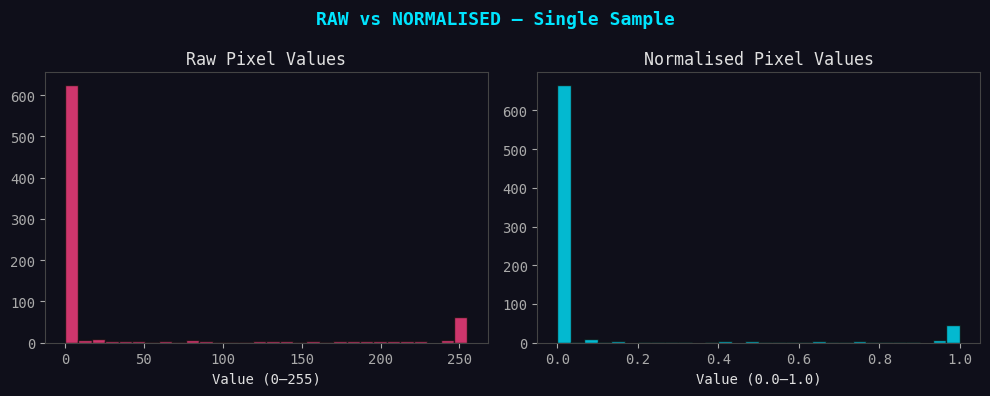

Saved → 06_normalisation.png


In [14]:
# ════════════════════════════════════════════════════════════
#  3. PRE-PROCESSING & NORMALISATION
# ════════════════════════════════════════════════════════════
# ── Separate features / labels ───────────────────────────────
X_train_raw = train_df.drop("label", axis=1).values.astype("float32")
y_train_raw = train_df["label"].values

X_test_raw  = test_df.drop("label", axis=1).values.astype("float32")
y_test_raw  = test_df["label"].values

# ── Normalise pixel values to [0, 1] ────────────────────────
X_train = X_train_raw / 255.0
X_test  = X_test_raw  / 255.0

print(f"\n✔  Pixel values normalised — range: [{X_train.min():.1f}, {X_train.max():.1f}]")
print(f"   X_train : {X_train.shape}  |  X_test : {X_test.shape}")

# ── Shuffle ──────────────────────────────────────────────────
X_train, y_train = shuffle(X_train, y_train_raw, random_state=42)
y_test = y_test_raw

# ── One-hot encode labels for training ───────────────────────
lb = LabelBinarizer()
y_train_oh = lb.fit_transform(y_train)
y_test_oh  = lb.transform(y_test)
print(f"   y_train_oh shape : {y_train_oh.shape}")

# ── Visualise normalised vs raw ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("RAW vs NORMALISED — Single Sample", fontsize=13, color=ACCENT, fontweight="bold")

axes[0].hist(X_train_raw[0], bins=30, color=ACCENT2, alpha=0.8, edgecolor="#111")
axes[0].set_title("Raw Pixel Values")
axes[0].set_xlabel("Value (0–255)")

axes[1].hist(X_train[0], bins=30, color=ACCENT, alpha=0.8, edgecolor="#111")
axes[1].set_title("Normalised Pixel Values")
axes[1].set_xlabel("Value (0.0–1.0)")

plt.tight_layout()
plt.savefig("06_normalisation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 06_normalisation.png")


Model: "MNIST_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571,018 (2.18 MB)

 Trainable params: 569,226 (2.17 MB)

 Non-trainable params: 1,792 (7.00 KB)

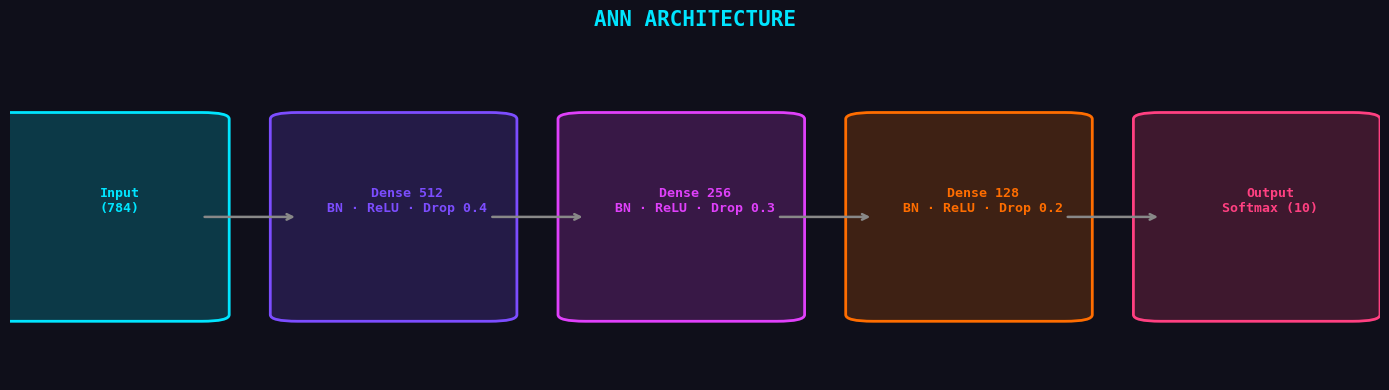

Saved → 07_ann_architecture.png


In [15]:
# ════════════════════════════════════════════════════════════
#  4. BUILD ANN MODEL
# ════════════════════════════════════════════════════════════
INPUT_DIM   = 784     # 28 × 28
NUM_CLASSES = 10

def build_ann(input_dim=784, num_classes=10):
    """
    Architecture
    ─────────────────────────────────────────────
    Input      → 784 neurons
    Dense 512  → BatchNorm → ReLU → Dropout 0.4
    Dense 256  → BatchNorm → ReLU → Dropout 0.3
    Dense 128  → BatchNorm → ReLU → Dropout 0.2
    Output 10  → Softmax
    """
    model = keras.Sequential([
        # ── Input ────────────────────────────────────
        layers.InputLayer(input_shape=(input_dim,)),

        # ── Hidden Layer 1 ───────────────────────────
        layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.4),

        # ── Hidden Layer 2 ───────────────────────────
        layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.3),

        # ── Hidden Layer 3 ───────────────────────────
        layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.2),

        # ── Output ───────────────────────────────────
        layers.Dense(num_classes, activation="softmax"),
    ], name="MNIST_ANN")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = build_ann()
model.summary()

# ── Visualise architecture ───────────────────────────────────
layer_names  = [l.name for l in model.layers]
layer_units  = []
for l in model.layers:
    try:
        layer_units.append(l.units)
    except AttributeError:
        layer_units.append(None)

# Draw ANN architecture diagram
unit_labels = [784, 512, 256, 128, 10]
arch_labels = ["Input\n(784)", "Dense 512\nBN · ReLU · Drop 0.4",
               "Dense 256\nBN · ReLU · Drop 0.3",
               "Dense 128\nBN · ReLU · Drop 0.2", "Output\nSoftmax (10)"]
colors      = ["#00e5ff", "#7c4dff", "#e040fb", "#ff6d00", "#ff4081"]

fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor("#0f0f1a")
ax.set_facecolor("#0f0f1a")

xs = np.linspace(0.08, 0.92, len(unit_labels))
for i, (x, label, color) in enumerate(zip(xs, arch_labels, colors)):
    ax.add_patch(mpatches.FancyBboxPatch((x - 0.08, 0.2), 0.14, 0.6,
                 boxstyle="round,pad=0.02", facecolor=color+"33",
                 edgecolor=color, linewidth=2, transform=ax.transAxes))
    ax.text(x, 0.55, label, ha="center", va="center",
            fontsize=9.5, color=color, fontweight="bold",
            transform=ax.transAxes, multialignment="center")
    if i < len(unit_labels) - 1:
        ax.annotate("", xy=(xs[i + 1] - 0.08, 0.5), xytext=(x + 0.06, 0.5),
                    xycoords="axes fraction", textcoords="axes fraction",
                    arrowprops=dict(arrowstyle="->", color="#888", lw=1.8))

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("ANN ARCHITECTURE", color=ACCENT, fontsize=15, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("07_ann_architecture.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 07_ann_architecture.png")




▶  Training started …

Epoch 1/50


I0000 00:00:1774715556.709192     129 service.cc:152] XLA service 0x329d42b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774715556.709251     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774715556.709258     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774715557.217081     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


 47/211 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5500 - loss: 1.5190

I0000 00:00:1774715560.467543     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


211/211 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.7663 - loss: 0.8598 - val_accuracy: 0.9475 - val_loss: 0.2701 - learning_rate: 0.0010
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9429 - loss: 0.2816 - val_accuracy: 0.9687 - val_loss: 0.1923 - learning_rate: 0.0010
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9582 - loss: 0.2289 - val_accuracy: 0.9698 - val_loss: 0.1875 - learning_rate: 0.0010
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9638 - loss: 0.2031 - val_accuracy: 0.9763 - val_loss: 0.1642 - learning_rate: 0.0010
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9706 - loss: 0.1820 - val_accuracy: 0.9755 - val_loss: 0.1628 - learning_rate: 0.0010
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9731 - loss: 0.1704 - val_accuracy: 0.9773 - val_loss: 0.1544 - learning_rate: 0.0010
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9753 - loss: 0.1586 - val_accur

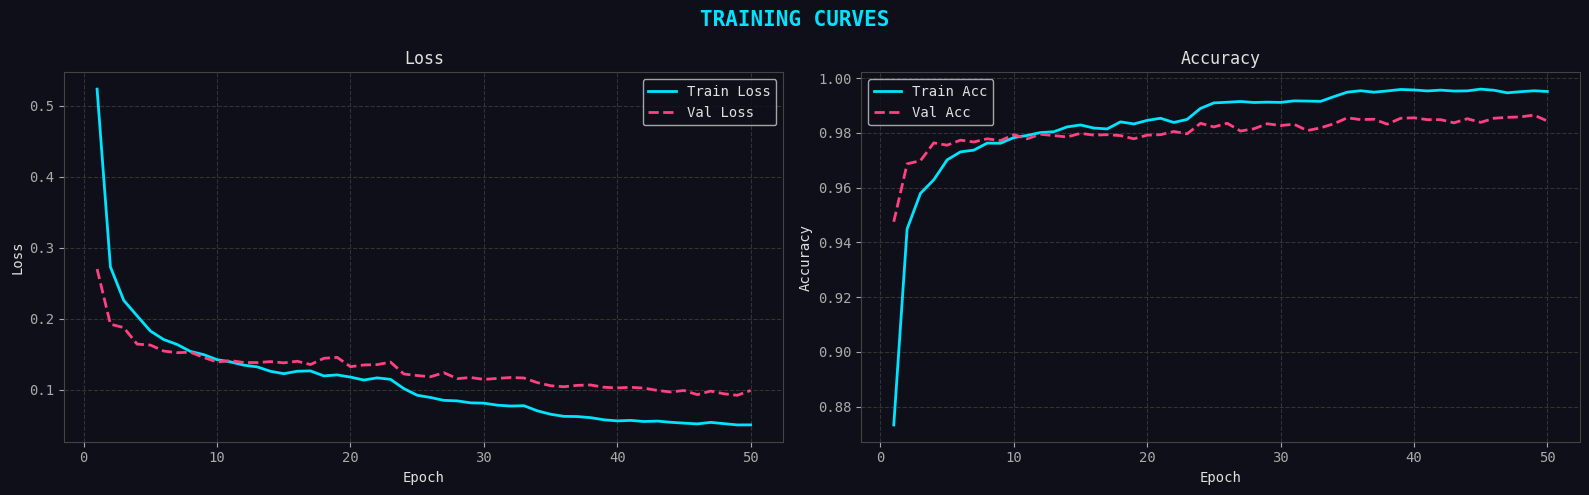

Saved → 08_training_curves.png


In [16]:
# ════════════════════════════════════════════════════════════
#  5. TRAIN THE MODEL
# ════════════════════════════════════════════════════════════
BATCH_SIZE = 256
EPOCHS     = 50

callbacks = [
    EarlyStopping(monitor="val_loss", patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
]

print("\n▶  Training started …\n")
history = model.fit(
    X_train, y_train_oh,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1,
)
print("\n✔  Training complete!")


# ── 5.1  Training Curves ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("TRAINING CURVES", fontsize=15, color=ACCENT, fontweight="bold")

ep = range(1, len(history.history["loss"]) + 1)

axes[0].plot(ep, history.history["loss"],     color=ACCENT,  lw=2, label="Train Loss")
axes[0].plot(ep, history.history["val_loss"], color=ACCENT2, lw=2, label="Val Loss", linestyle="--")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(ep, history.history["accuracy"],     color=ACCENT,  lw=2, label="Train Acc")
axes[1].plot(ep, history.history["val_accuracy"], color=ACCENT2, lw=2, label="Val Acc", linestyle="--")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig("08_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 08_training_curves.png")

In [17]:
# ════════════════════════════════════════════════════════════
#  6. EVALUATE & PREDICT
# ════════════════════════════════════════════════════════════
test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)
print(f"\n── TEST SET RESULTS ────────────────────────")
print(f"   Loss     : {test_loss:.4f}")
print(f"   Accuracy : {test_acc * 100:.2f}%")

# ── Predict ──────────────────────────────────────────────────
y_prob  = model.predict(X_test, verbose=0)
y_pred  = np.argmax(y_prob, axis=1)
y_true  = y_test

# ── Per-class metrics ────────────────────────────────────────
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="weighted")
rec  = recall_score(y_true, y_pred, average="weighted")
f1   = f1_score(y_true, y_pred, average="weighted")

print(f"\n── METRICS (Weighted) ──────────────────────")
print(f"   Accuracy  : {acc  * 100:.2f}%")
print(f"   Precision : {prec * 100:.2f}%")
print(f"   Recall    : {rec  * 100:.2f}%")
print(f"   F1-Score  : {f1   * 100:.2f}%")

# ── Full Classification Report ───────────────────────────────
print("\n── CLASSIFICATION REPORT ───────────────────")
print(classification_report(y_true, y_pred,
                             target_names=[str(i) for i in range(10)]))




── TEST SET RESULTS ────────────────────────
   Loss     : 0.0945
   Accuracy : 98.52%

── METRICS (Weighted) ──────────────────────
   Accuracy  : 98.52%
   Precision : 98.52%
   Recall    : 98.52%
   F1-Score  : 98.52%

── CLASSIFICATION REPORT ───────────────────
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.98      0.99      1032
           3       0.98      0.99      0.98      1010
           4       0.98      0.99      0.98       982
           5       0.99      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99     

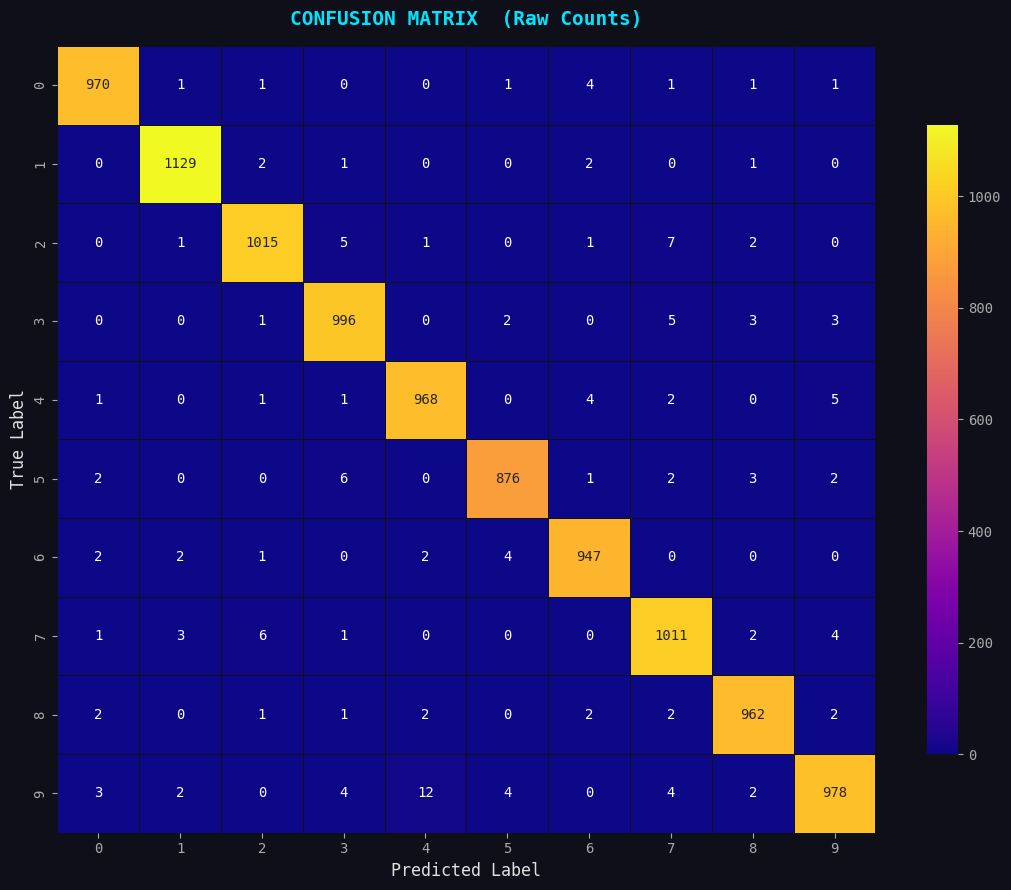

Saved → 09_confusion_matrix.png


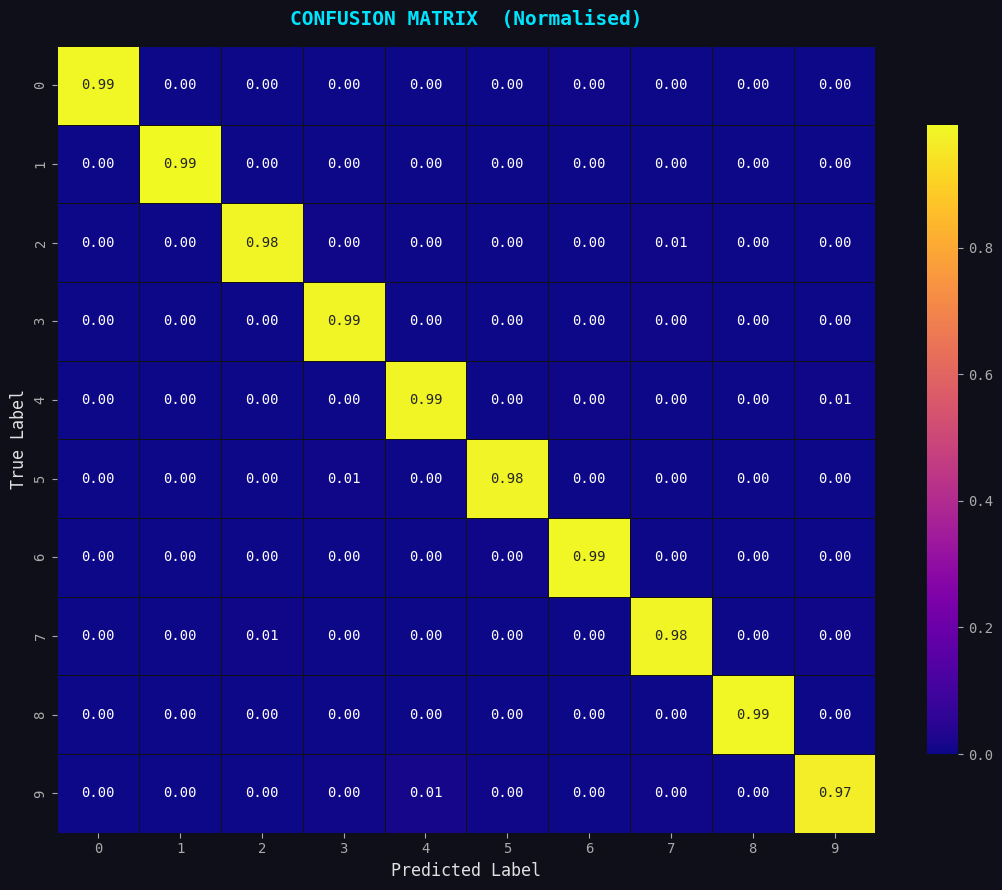

Saved → 10_confusion_matrix_norm.png


In [19]:
# ════════════════════════════════════════════════════════════
#  7. CONFUSION MATRIX
# ════════════════════════════════════════════════════════════
cm = confusion_matrix(y_true, y_pred)

# ── Raw count heatmap ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt="d", cmap="plasma",
            xticklabels=range(10), yticklabels=range(10),
            linewidths=0.4, linecolor="#111", ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("CONFUSION MATRIX  (Raw Counts)", fontsize=14,
             color=ACCENT, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("09_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 09_confusion_matrix.png")

# ── Normalised heatmap ───────────────────────────────────────
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="plasma",
            xticklabels=range(10), yticklabels=range(10),
            linewidths=0.4, linecolor="#111", ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("CONFUSION MATRIX  (Normalised)", fontsize=14,
             color=ACCENT, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("10_confusion_matrix_norm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 10_confusion_matrix_norm.png")

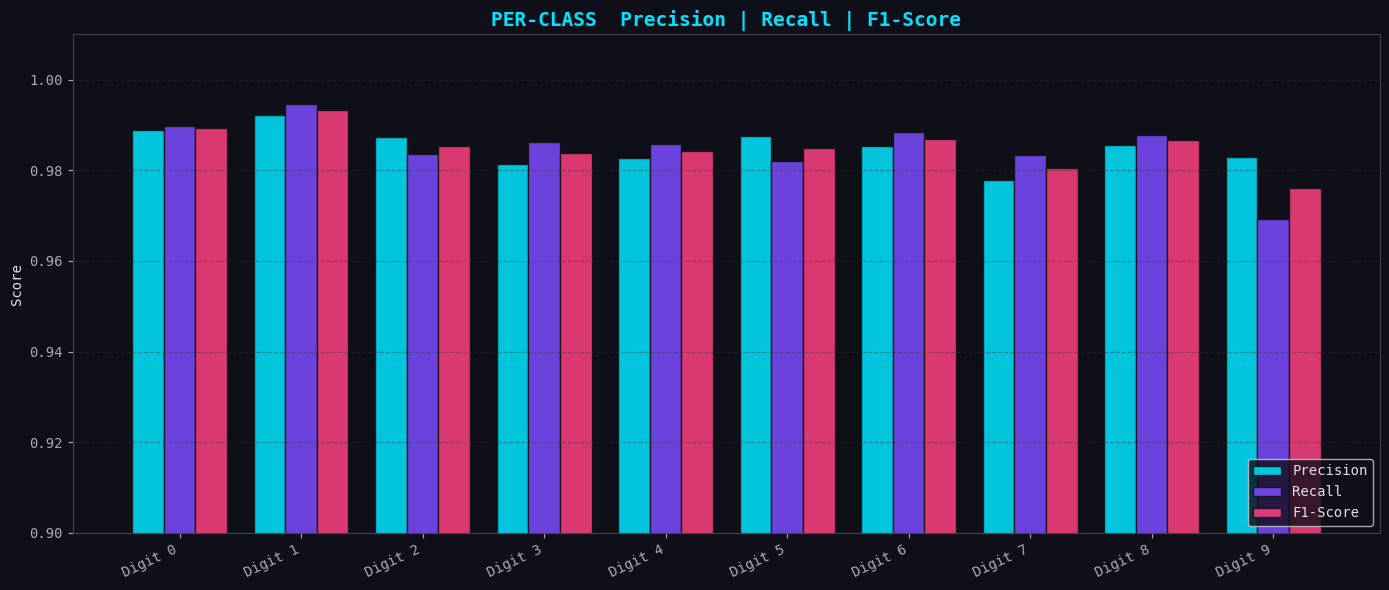

Saved → 11_per_class_metrics.png


In [20]:
# ════════════════════════════════════════════════════════════
#  8. PER-CLASS METRICS BAR CHART
# ════════════════════════════════════════════════════════════
report = classification_report(y_true, y_pred,
                                target_names=[str(i) for i in range(10)],
                                output_dict=True)

digits     = [str(i) for i in range(10)]
prec_vals  = [report[d]["precision"] for d in digits]
rec_vals   = [report[d]["recall"]    for d in digits]
f1_vals    = [report[d]["f1-score"]  for d in digits]

x = np.arange(10)
w = 0.26

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w, prec_vals, width=w, label="Precision", color="#00e5ff", alpha=0.85, edgecolor="#111")
ax.bar(x,     rec_vals,  width=w, label="Recall",    color="#7c4dff", alpha=0.85, edgecolor="#111")
ax.bar(x + w, f1_vals,   width=w, label="F1-Score",  color="#ff4081", alpha=0.85, edgecolor="#111")

ax.set_xticks(x)
ax.set_xticklabels([f"Digit {d}" for d in digits], rotation=25, ha="right")
ax.set_ylim(0.9, 1.01)
ax.set_ylabel("Score")
ax.set_title("PER-CLASS  Precision | Recall | F1-Score",
             color=ACCENT, fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("11_per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 11_per_class_metrics.png")



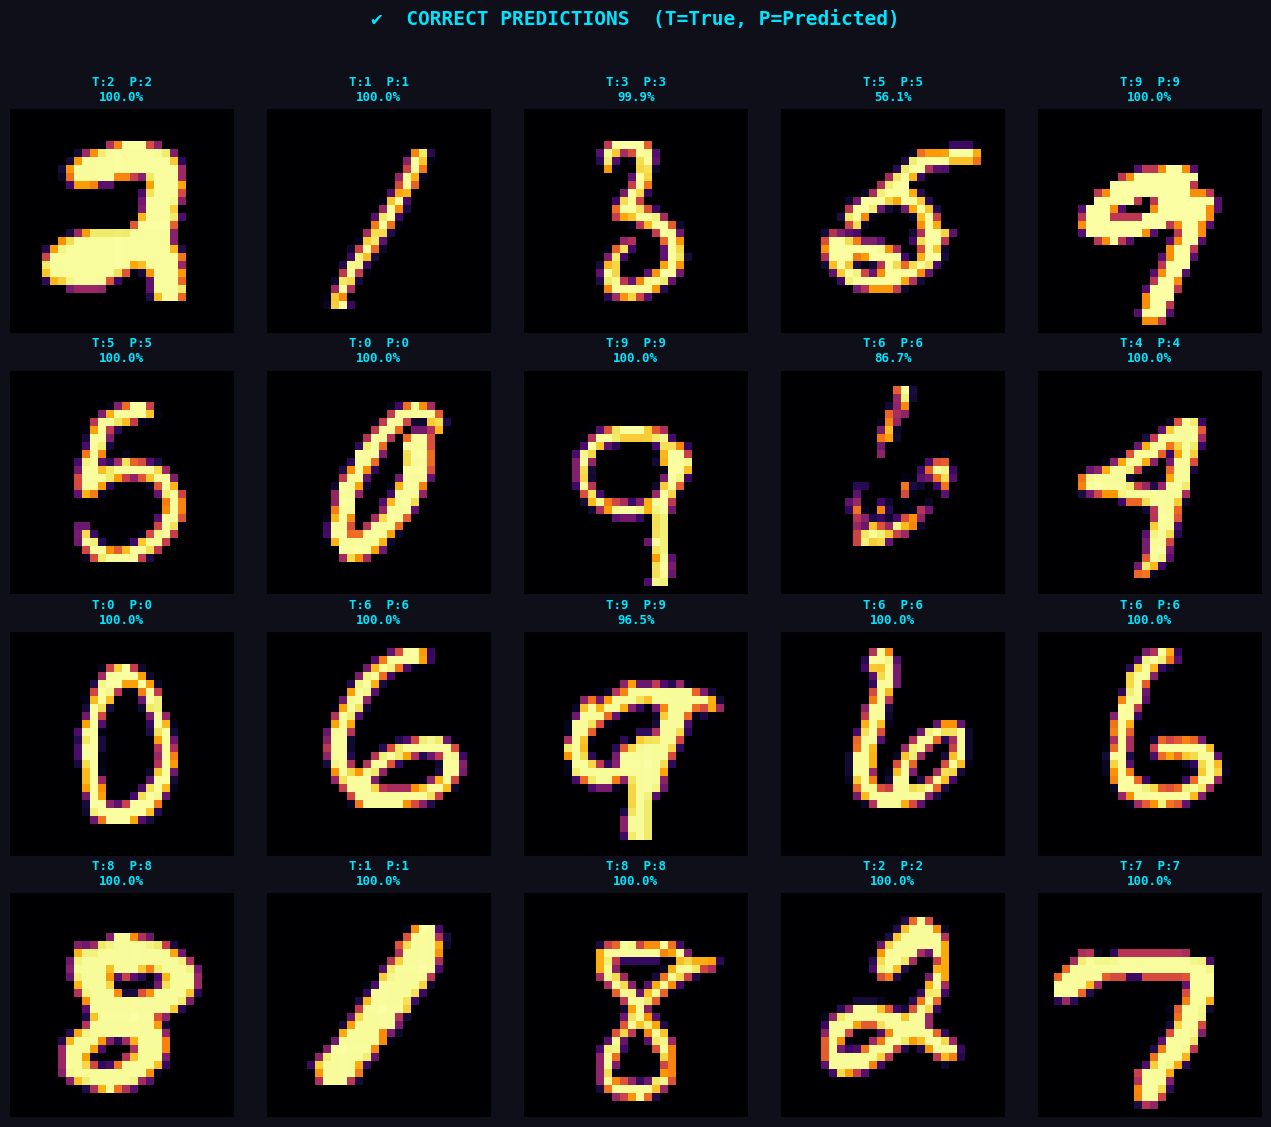

Saved → 12_correct_predictions.png


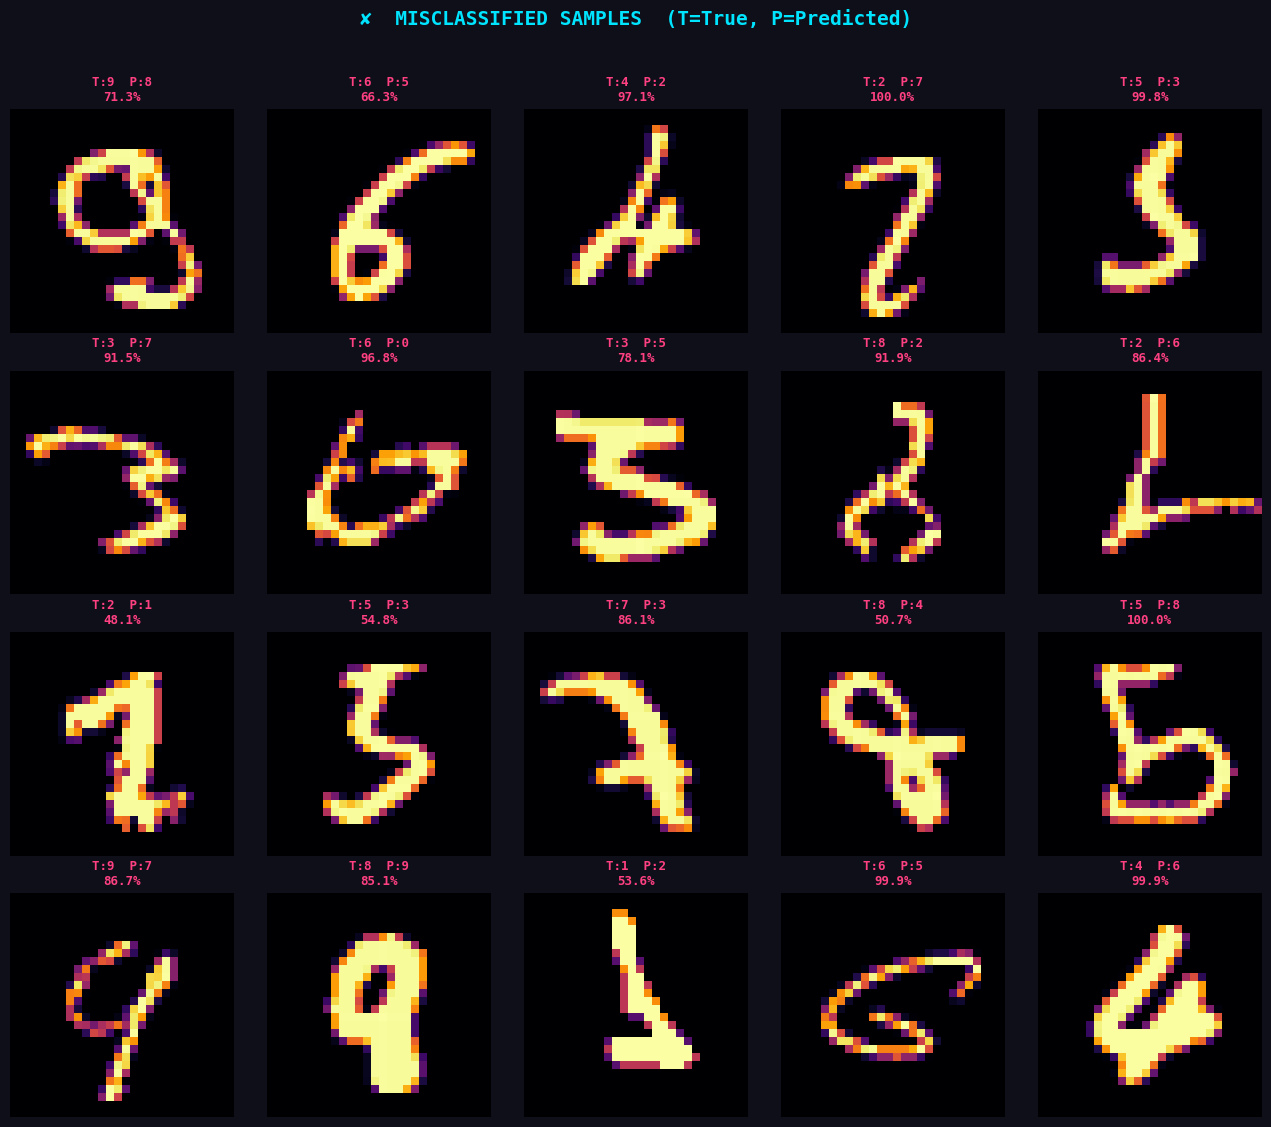

Saved → 13_wrong_predictions.png


In [21]:
# ════════════════════════════════════════════════════════════
#  9. SAMPLE PREDICTIONS (Correct & Wrong)
# ════════════════════════════════════════════════════════════
# ── Correct predictions ──────────────────────────────────────
correct_idx = np.where(y_pred == y_true)[0]
wrong_idx   = np.where(y_pred != y_true)[0]

def plot_samples(indices, title, filename, n=20):
    rows, cols = 4, 5
    fig, axes  = plt.subplots(rows, cols, figsize=(13, 11))
    fig.suptitle(title, fontsize=14, color=ACCENT, fontweight="bold", y=1.02)
    axes = axes.flatten()

    for ax, idx in zip(axes, indices[:n]):
        img   = X_test[idx].reshape(28, 28)
        pred  = y_pred[idx]
        true  = y_true[idx]
        conf  = y_prob[idx][pred] * 100
        color = "#00e5ff" if pred == true else "#ff4081"

        ax.imshow(img, cmap="inferno", interpolation="nearest")
        ax.set_title(f"T:{true}  P:{pred}\n{conf:.1f}%",
                     color=color, fontsize=9, fontweight="bold")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {filename}")

rng = np.random.default_rng(42)
plot_samples(rng.choice(correct_idx, 20, replace=False),
             "✔  CORRECT PREDICTIONS  (T=True, P=Predicted)",
             "12_correct_predictions.png")

plot_samples(wrong_idx,
             "✘  MISCLASSIFIED SAMPLES  (T=True, P=Predicted)",
             "13_wrong_predictions.png")


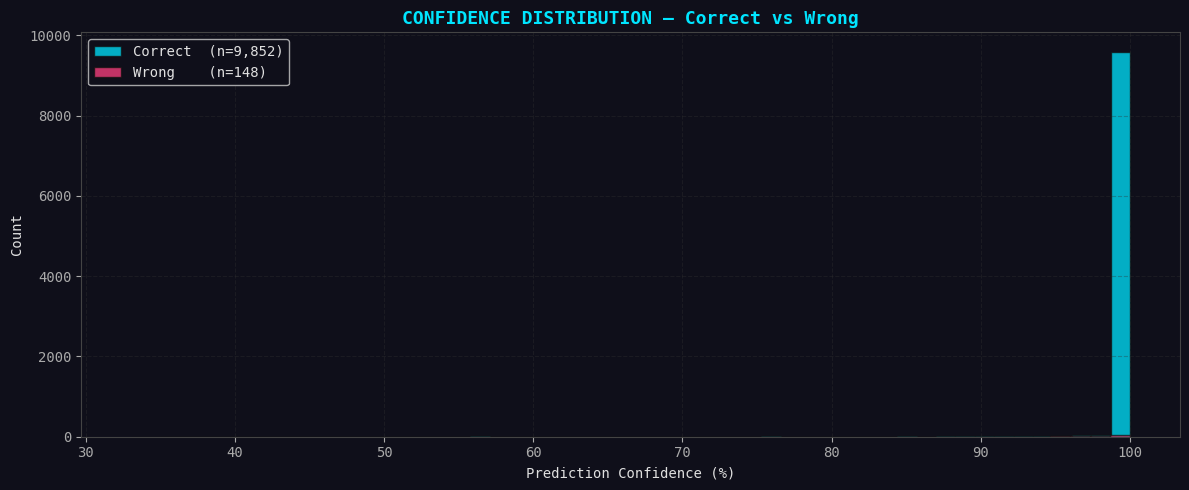

Saved → 14_confidence_distribution.png


In [22]:
# ════════════════════════════════════════════════════════════
# 10. CONFIDENCE DISTRIBUTION
# ════════════════════════════════════════════════════════════
max_conf_correct = y_prob[correct_idx].max(axis=1) * 100
max_conf_wrong   = y_prob[wrong_idx  ].max(axis=1) * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(max_conf_correct, bins=50, color=ACCENT,  alpha=0.75,
        label=f"Correct  (n={len(correct_idx):,})", edgecolor="#111")
ax.hist(max_conf_wrong,   bins=50, color=ACCENT2, alpha=0.75,
        label=f"Wrong    (n={len(wrong_idx):,})",   edgecolor="#111")
ax.set_xlabel("Prediction Confidence (%)")
ax.set_ylabel("Count")
ax.set_title("CONFIDENCE DISTRIBUTION — Correct vs Wrong",
             color=ACCENT, fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig("14_confidence_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 14_confidence_distribution.png")

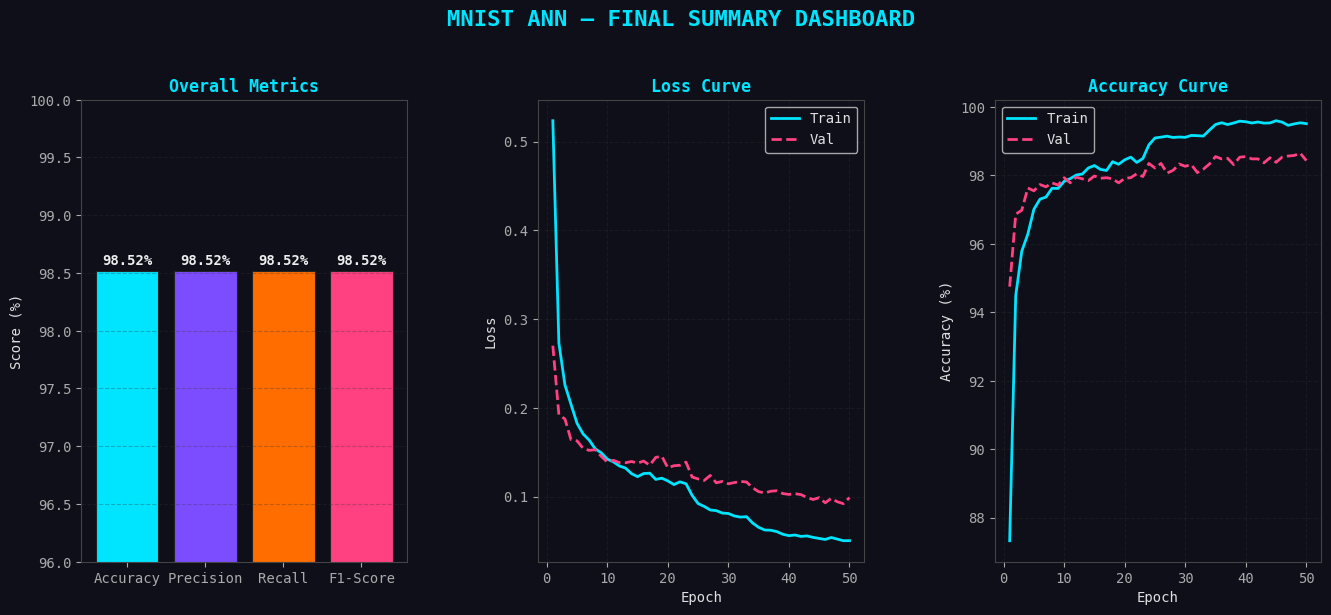

Saved → 15_summary_dashboard.png


In [23]:
# ════════════════════════════════════════════════════════════
# 11. SUMMARY DASHBOARD
# ════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 6))
fig.patch.set_facecolor("#0f0f1a")

gs   = gridspec.GridSpec(1, 3, figure=fig, wspace=0.4)
ax1  = fig.add_subplot(gs[0])
ax2  = fig.add_subplot(gs[1])
ax3  = fig.add_subplot(gs[2])

# ── Metric summary bars ──────────────────────────────────────
metrics = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}
clrs    = [ACCENT, "#7c4dff", "#ff6d00", ACCENT2]
bars    = ax1.bar(metrics.keys(), [v * 100 for v in metrics.values()],
                  color=clrs, edgecolor="#222", linewidth=0.8)
ax1.set_ylim(96, 100)
ax1.set_ylabel("Score (%)")
ax1.set_title("Overall Metrics", color=ACCENT, fontweight="bold")
for bar, v in zip(bars, metrics.values()):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f"{v * 100:.2f}%", ha="center", fontsize=10, color="#eee", fontweight="bold")
ax1.grid(True, axis="y", alpha=0.3)

# ── Loss curve ───────────────────────────────────────────────
ep2 = range(1, len(history.history["loss"]) + 1)
ax2.plot(ep2, history.history["loss"],     color=ACCENT,  lw=2, label="Train")
ax2.plot(ep2, history.history["val_loss"], color=ACCENT2, lw=2, label="Val", linestyle="--")
ax2.set_title("Loss Curve", color=ACCENT, fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.legend(); ax2.grid(True, alpha=0.3)

# ── Accuracy curve ───────────────────────────────────────────
ax3.plot(ep2, [v * 100 for v in history.history["accuracy"]],
         color=ACCENT,  lw=2, label="Train")
ax3.plot(ep2, [v * 100 for v in history.history["val_accuracy"]],
         color=ACCENT2, lw=2, label="Val", linestyle="--")
ax3.set_title("Accuracy Curve", color=ACCENT, fontweight="bold")
ax3.set_xlabel("Epoch"); ax3.set_ylabel("Accuracy (%)")
ax3.legend(); ax3.grid(True, alpha=0.3)

fig.suptitle("MNIST ANN — FINAL SUMMARY DASHBOARD",
             fontsize=16, color=ACCENT, fontweight="bold", y=1.03)

plt.savefig("15_summary_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 15_summary_dashboard.png")

In [24]:
# ════════════════════════════════════════════════════════════
# 12. SAVE MODEL
# ════════════════════════════════════════════════════════════
model.save("mnist_ann_model.h5")
print("\n✔  Model saved → mnist_ann_model.h5")

# ── Final summary ────────────────────────────────────────────
print("\n" + "═" * 52)
print("  FINAL RESULTS")
print("═" * 52)
print(f"  Accuracy  : {acc  * 100:.4f}%")
print(f"  Precision : {prec * 100:.4f}%")
print(f"  Recall    : {rec  * 100:.4f}%")
print(f"  F1-Score  : {f1   * 100:.4f}%")
print(f"  Test Loss : {test_loss:.4f}")
print("═" * 52)
print("  ALL PLOTS SAVED  (01 – 15)")
print("═" * 52)


✔  Model saved → mnist_ann_model.h5

════════════════════════════════════════════════════
  FINAL RESULTS
════════════════════════════════════════════════════
  Accuracy  : 98.5200%
  Precision : 98.5203%
  Recall    : 98.5200%
  F1-Score  : 98.5194%
  Test Loss : 0.0945
════════════════════════════════════════════════════
  ALL PLOTS SAVED  (01 – 15)
════════════════════════════════════════════════════
